# Setup

## Import packages

In [1]:
# === System and Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
from dotenv import load_dotenv

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial and Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim
import requests

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing ===
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### check_table_info

In [2]:
def check_table_info(target_df):
    """
    To check the unique values, dtype, example, missing rate of each column
    """
    table_info = []
    for col in target_df:
        table_info_row = []
        table_info_row.append(col)
        table_info_row.append(target_df[col].nunique())
        table_info_row.append(target_df[col].dtype)
        table_info_row.append(target_df[col].iloc[0])
        table_info_row.append(round(target_df[col].isna().sum() / target_df.shape[0]*100,2))

        table_info.append(table_info_row)
    res = pd.DataFrame(table_info, columns=['col_name', 'unique_values', 'dtype', 'example', 'missing%'])

    return res

### plot_feature_correlation_heatmap

In [3]:
def cramers_v(chi2, n, r, c):
    """Compute Cramér's V for categorical feature association"""
    denom = n * min(r - 1, c - 1)
    if denom == 0:
        return np.nan
    return np.sqrt(chi2 / denom)

In [4]:
def cramers_v_from_dataframe(x, y):
    """
    Calculate Cramér's V between two categorical pandas Series.
    
    Args:
        x (pd.Series): First categorical variable.
        y (pd.Series): Second categorical variable.
    
    Returns:
        float: Cramér's V statistic.
    """
    contingency_table = pd.crosstab(x, y)
    if contingency_table.shape[0] <= 1 or contingency_table.shape[1] <= 1:
        return np.nan 
    chi2, _, _, _ = chi2_contingency(contingency_table, correction=False)
    n = contingency_table.sum().sum()
    r, c = contingency_table.shape
    return cramers_v(chi2, n, r, c)

In [5]:
def plot_feature_correlation_heatmap(input_df, input_features, kind="categorical"):
    """
    Plots a correlation heatmap for the selected features.

    Parameters:
        1. input_df (pd.DataFrame): The input DataFrame containing the features.
        2. input_features (list): A list of column names to include in the correlation heatmap.
                                 ❗All features in the list must be of the same type (categorical or continuous).
        3. kind (str): Type of features to analyze. Acceptable values:
                       - "categorical": computes pairwise Cramér's V between categorical features.
                       - "continuous" : computes Pearson correlation between numeric features.

    Returns:
        A Seaborn heatmap displaying pairwise feature correlations.
    """
    if kind == "categorical":
        corr_matrix = pd.DataFrame(index=input_features, columns=input_features)
        for col1 in input_features:
            for col2 in input_features:
                corr_matrix.loc[col1, col2] = cramers_v_from_dataframe(input_df[col1], input_df[col2])
        corr_matrix = corr_matrix.astype(float)
    elif kind == "continuous":
        corr_matrix = input_df[input_features].corr()
    else:
        raise ValueError("Invalid `kind`. Use 'categorical' or 'continuous'.")

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        mask=mask,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    title = f"Feature Correlation Heatmap ({kind} variables)"
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

### encode_features

In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def encode_features(input_df, input_features, drop_first=True):
    """
    Transforms input features for modeling:
    
    - Boolean features are converted to integers (0 or 1).
    - Categorical features (dtype 'category') are one-hot encoded.
        - Optionally drops the first dummy column to avoid multicollinearity.
    - Numerical (continuous) features are standardized using StandardScaler.
    
    Tracks:
    - The original-to-transformed column mappings.
    - Which dummy columns (baseline categories) were dropped.

    Args:
        input_df (pd.DataFrame): Original input DataFrame.
        input_features (list): List of column names to transform.
        drop_first (bool): Whether to drop the first dummy variable for each categorical feature.

    Returns:
        encoded_df (pd.DataFrame): Final encoded DataFrame ready for modeling.
        drop_col_df (pd.DataFrame): Info about dropped dummy columns (if any).
        mapping_df (pd.DataFrame): Mapping from original features to encoded columns.
    """
    encoded_df = pd.DataFrame(index=input_df.index)
    drop_col_records = []
    mapping_records = []

    for feature in input_features:
        series = input_df[feature]

        if series.dtype.name == 'bool':
            # Convert boolean to integer (0/1)
            encoded_df[feature] = series.astype(int)
            mapping_records.append({'original_feature': feature, 'feature': feature})

        elif series.dtype.name == 'category':
            # One-hot encode categorical
            dummies = pd.get_dummies(series, prefix=feature, prefix_sep='_', drop_first=False)

            for dummy_col in dummies.columns:
                mapping_records.append({'original_feature': feature, 'feature': dummy_col})

            if drop_first:
                dropped_col = dummies.columns[0]
                drop_col_records.append({
                    'original_feature': feature,
                    'baseline_category': dropped_col,
                    'true_cases': dummies[dropped_col].sum()
                })
                dummies.drop(columns=[dropped_col], inplace=True)

            encoded_df = pd.concat([encoded_df, dummies], axis=1)

        else:
            # Standardize numeric feature
            scaler = StandardScaler()
            standardized = scaler.fit_transform(series.values.reshape(-1, 1))
            encoded_df[feature] = standardized.flatten()
            mapping_records.append({'original_feature': feature, 'feature': feature})

    drop_col_df = pd.DataFrame(drop_col_records)
    mapping_df = pd.DataFrame(mapping_records)

    return encoded_df, drop_col_df, mapping_df

### classification_evaluation

In [7]:
def classification_evaluation(y_actual, y_pred):
    """
    Prints a full evaluation report for multiclass classification results.

    Shows:
    - Accuracy
    - Precision (macro)
    - Recall (macro)
    - F1 score (macro)
    - Confusion matrix
    - Classification report

    Args:
        y_actual (array-like): True class labels
        y_pred (array-like): Predicted class labels
    """

    print("Accuracy       :", round(accuracy_score(y_actual, y_pred), 3))
    print("Precision Score:", round(precision_score(y_actual, y_pred, average='macro'), 3))
    print("Recall Score   :", round(recall_score(y_actual, y_pred, average='macro'), 3))
    print("F1 Score       :", round(f1_score(y_actual, y_pred, average='macro'), 3))
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred, zero_division=1))

### predict_sample_dataset

In [8]:
def convert_percentile_to_level(series):
    """
    Convert continuous percentile values to 5-level categorical bins
    (equal-width binning from min to max).
    """
    min_val = series.min()
    max_val = series.max()
    bins = np.linspace(min_val, max_val, 6)  # 5 bins
    labels = ['1', '2', '3', '4', '5']

    result = pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return result

In [9]:
def predict_sample_dataset(model, input_X, input_y, 
                           sample_size=1000000, 
                           y_type='categorical', 
                           is_lgbm=False, is_cat=False,
                           eval_metric=None):
    """
    Train and evaluate a model on a sampled dataset.

    Parameters:
        model: sklearn, LightGBM, or CatBoost model
        input_X (DataFrame): feature set
        input_y (Series): target
        sample_size (int): max sample size
        y_type (str): 'continuous' or 'categorical'
        is_lgbm (bool): use LGBM-style training
        is_cat (bool): use CatBoost-style training
        eval_metric (str): metric for model evaluation
    """

    if y_type not in ['continuous', 'categorical']:
        raise ValueError('y_type must be "continuous" or "categorical"')

    # Sample
    X_sample = input_X.sample(n=min(sample_size, len(input_X)), random_state=42)
    y_sample = input_y.loc[X_sample.index]

    # Split
    stratify_arg = y_sample if y_type == 'categorical' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, stratify=stratify_arg, random_state=42
    )

    cat_features = X_sample.select_dtypes('category').columns.tolist()

    # Fit
    if not is_lgbm and not is_cat:
        model.fit(X_train, y_train)
    elif is_lgbm:
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=eval_metric,
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(10)]
        )
    elif is_cat:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            cat_features=cat_features)

    # Predict
    y_pred = model.predict(X_test)

    # Optional fix for CatBoost regression/classification float output
    if is_cat and y_type == 'categorical' and not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.round(y_pred).astype(int)

    # Evaluate
    if y_type == 'continuous':
        y_test_label = convert_percentile_to_level(pd.Series(y_test).reset_index(drop=True))
        y_pred_label = convert_percentile_to_level(pd.Series(y_pred).reset_index(drop=True))
    else:
        y_test_label = y_test
        y_pred_label = y_pred

    classification_evaluation(y_test_label, y_pred_label)

# Data Preparation

## Load the dataset

In [10]:
# Load combined_df
combined_df = pd.read_pickle('combined_light_with_busyness_level.pkl')

In [11]:
combined_df.columns

Index(['date', 'hour', 'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm',
       'grid_id', 'lat', 'lon', 'geometry', 'is_holiday', 'restaurant_count',
       'subway_grid_ridership', 'subway_buffer_ridership', 'bike_grid_trips',
       'bike_buffer_ridership', 'taxi_passenger_count', 'event_count',
       'population', 'busyness_percentile', 'busyness_level'],
      dtype='object')

In [12]:
# Extract more date related data and convert them to category datatype
combined_df['grid_id'] = combined_df['grid_id'].astype('category')
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['month'] = combined_df['date'].dt.month.astype('category')
combined_df['weekofyear'] = combined_df['date'].dt.isocalendar().week.astype('category')
combined_df['dayofweek'] = combined_df['date'].dt.dayofweek.astype('category')
combined_df['is_weekend'] = combined_df['dayofweek'].astype('int') >= 5
combined_df['day'] = combined_df['date'].dt.day.astype('category')
combined_df['hour'] = combined_df['hour'].astype('category')
combined_df['is_holiday'] = combined_df['is_holiday'].astype('category')
combined_df['is_weekend'] = combined_df['is_weekend'].astype('category')

In [13]:
check_table_info(combined_df)

,col_name,unique_values,dtype,example,missing%
0,date,365,datetime64[ns],2024-04-01 00:00:00,0.0
1,hour,24,category,0,0.0
2,temp_c,105,float64,13.3,0.0
3,dew_c,106,float64,-0.6,0.0
4,wind_speed_knot,20,float64,0.0,0.0
5,precip_mm,40,float64,0.0,0.0
6,grid_id,1140,category,M-0001,0.0
7,lat,172,float64,40.684,0.0
8,lon,50,float64,-74.0257,0.0
9,geometry,1140,geometry,POLYGON ((-74.02420021522046 40.68291694544539...,0.0


In [14]:
X_origin = combined_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                        'grid_id', 'restaurant_count', 'population', # grid info
                        'lat', 'lon', # could be removed
                        'event_count', # event
                       ]]
y_origin = combined_df['busyness_level']
check_table_info(X_origin)

,col_name,unique_values,dtype,example,missing%
0,month,12,category,4,0.0
1,weekofyear,52,category,14,0.0
2,dayofweek,7,category,0,0.0
3,is_weekend,2,category,False,0.0
4,day,31,category,1,0.0
5,hour,24,category,0,0.0
6,is_holiday,2,category,False,0.0
7,temp_c,105,float64,13.3,0.0
8,dew_c,106,float64,-0.6,0.0
9,wind_speed_knot,20,float64,0.0,0.0


## Split the dataset into two datasets

In [15]:
# Take a third (random) data samples as test data, rest as training data
X_train_origin, X_test_origin, y_train_origin, y_test_origin = train_test_split(X_origin, y_origin, test_size=0.3, random_state=42)

In [16]:
# Confirm the percentage
print(X_train_origin.shape[0] / X_origin.shape[0])
print(X_test_origin.shape[0] / X_origin.shape[0])

0.7
0.3


## Explore the relationships on the training set

### Correlations between all the continuous features

Index(['temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', 'restaurant_count',
       'population', 'lat', 'lon', 'event_count'],
      dtype='object')


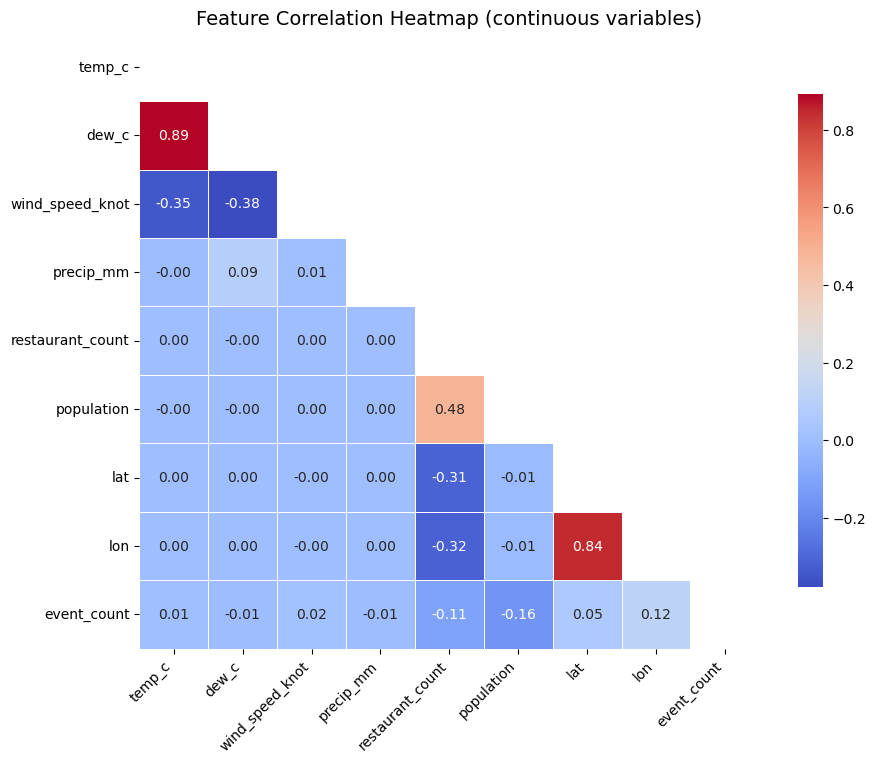

In [17]:
continuos_features = X_train_origin.select_dtypes(['int', 'float'])
print(continuos_features.columns)
plot_feature_correlation_heatmap(X_train_origin, continuos_features.columns, 'continuous')

### Correlations between all the categorical features

Index(['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour',
       'is_holiday', 'grid_id'],
      dtype='object')


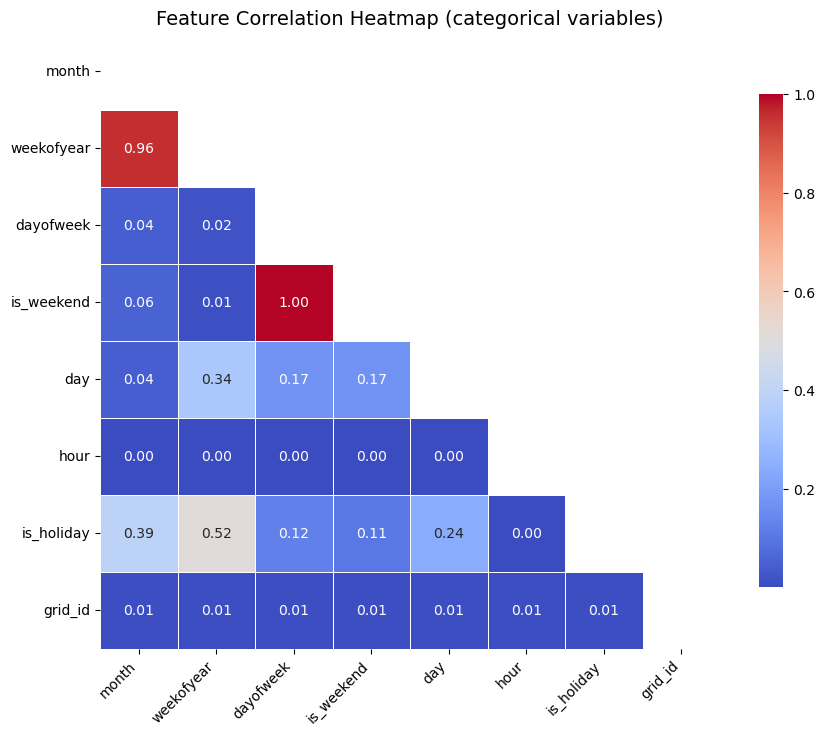

In [18]:
categorical_features = X_train_origin.select_dtypes(['category'])
print(categorical_features.columns)
plot_feature_correlation_heatmap(X_train_origin, categorical_features.columns, 'categorical')

# Model prediction - Classification
- Use `busyness_level` from `busyness_score_grid.ipynb` as target variable
- LightGBM has the best performance on sample dataset

## 1. SGDClassifier
- Efficient version of logistic regression or SVM for large-scale data
- Bad performance on sample dataset (1M)
  - Accuracy       : 0.748
  - Precision Score: 0.477
  - Recall Score   : 0.367
  - F1 Score       : 0.335
- Too slow for the whole dataset

In [19]:
sgd = SGDClassifier(
    loss='log_loss',          
    max_iter=1000,
    tol=1e-3,
    learning_rate='optimal',
    random_state=42
)

In [20]:
X_sgd = X_origin.drop(columns=['grid_id']) # Too large to encode as dummy
y_sgd = y_origin.copy()

X_sgd, _, feature_mapping_log = encode_features(X_sgd, X_sgd.columns, drop_first=True)
y_sgd = y_sgd.astype(int) - 1

X_sgd.shape

(9986400, 132)

### Sample dataset

Accuracy       : 0.748
Precision Score: 0.477
Recall Score   : 0.367
F1 Score       : 0.335



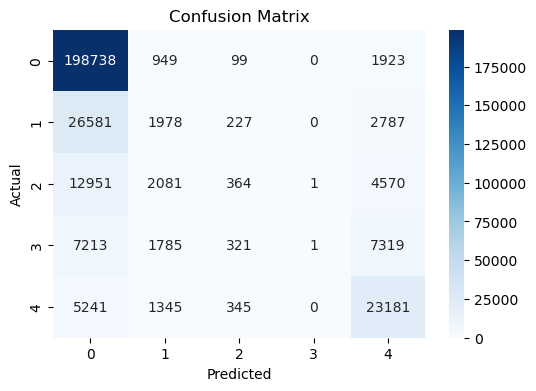


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88    201709
           1       0.24      0.06      0.10     31573
           2       0.27      0.02      0.03     19967
           3       0.50      0.00      0.00     16639
           4       0.58      0.77      0.66     30112

    accuracy                           0.75    300000
   macro avg       0.48      0.37      0.34    300000
weighted avg       0.66      0.75      0.67    300000



In [21]:
predict_sample_dataset(model=sgd, 
                       input_X=X_sgd, 
                       input_y=y_sgd, 
                       sample_size=1000000)

### Full dataset
- Takes too long to run

In [22]:
# X_train_sgd, X_test_sgd, y_train_sgd, y_test_ = train_test_split(X_sgd, y_sgd, test_size=0.3, random_state=42)
# sgd.fit(X_train_sgd, y_train_sgd)
# y_pred_sgd = sgd.predict(X_test_sgd)

# classification_evaluation(y_test_sgd, y_pred_sgd)

## 2. Logistic Regression
- Performance on sample dataset is similar to SGDClassifier
  - Accuracy       : 0.753
  - Precision Score: 0.442
  - Recall Score   : 0.395
  - F1 Score       : 0.376

In [23]:
logreg = LogisticRegression(max_iter=3000)

### Sample Dataset

Accuracy       : 0.753
Precision Score: 0.443
Recall Score   : 0.395
F1 Score       : 0.376



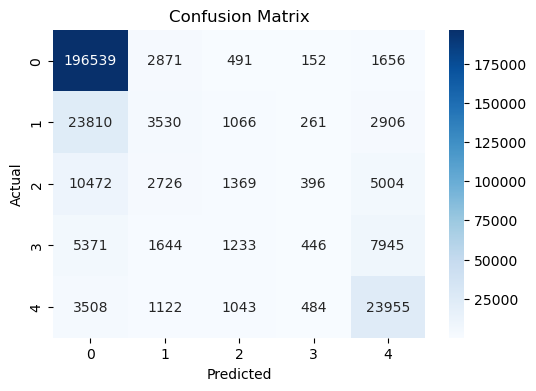


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89    201709
           1       0.30      0.11      0.16     31573
           2       0.26      0.07      0.11     19967
           3       0.26      0.03      0.05     16639
           4       0.58      0.80      0.67     30112

    accuracy                           0.75    300000
   macro avg       0.44      0.40      0.38    300000
weighted avg       0.67      0.75      0.69    300000



In [24]:
# Reuse the dataset generated for SGDClassifier
predict_sample_dataset(model=logreg, 
                       input_X=X_sgd, 
                       input_y=y_sgd, 
                       sample_size=1000000)

## 3. HistGradientBoostingClassifier
- Tree-based boosting (scikit-learn’s version of LightGBM)
- Sample dataset:
  - Accuracy       : 0.831
  - Precision Score: 0.61
  - Recall Score   : 0.574
  - F1 Score       : 0.577
- Full dataset:
  - Accuracy       : 0.835
  - Precision Score: 0.623
  - Recall Score   : 0.584
  - F1 Score       : 0.589

- Although the model trained on the full dataset performs slightly better, it takes significantly longer to run. To facilitate faster model comparison, performance on the sampled dataset will be used instead.

In [25]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,
    max_depth=6,
    random_state=42
)

In [26]:
# Cannot accept > 255 cadinality, need to drop grid_id before processing
X_hgb = X_origin.drop(columns=['grid_id']) # Too large to encode as dummy
y_hgb = y_origin.copy()
y_hgb = y_hgb.astype(int) - 1

### Sample dataset

Accuracy       : 0.831
Precision Score: 0.613
Recall Score   : 0.574
F1 Score       : 0.578



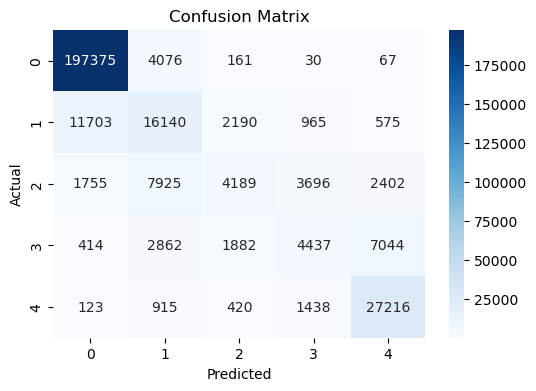


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96    201709
           1       0.51      0.51      0.51     31573
           2       0.47      0.21      0.29     19967
           3       0.42      0.27      0.33     16639
           4       0.73      0.90      0.81     30112

    accuracy                           0.83    300000
   macro avg       0.61      0.57      0.58    300000
weighted avg       0.81      0.83      0.81    300000



In [27]:
predict_sample_dataset(model=hgb, 
                       input_X=X_hgb, 
                       input_y=y_hgb, 
                       sample_size=1000000)

In [28]:
def predict_full_dataset(model, input_X, input_y):
    X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.3, stratify=input_y, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    classification_evaluation(y_test, y_pred)

### Full dataset

Accuracy       : 0.835
Precision Score: 0.623
Recall Score   : 0.584
F1 Score       : 0.59



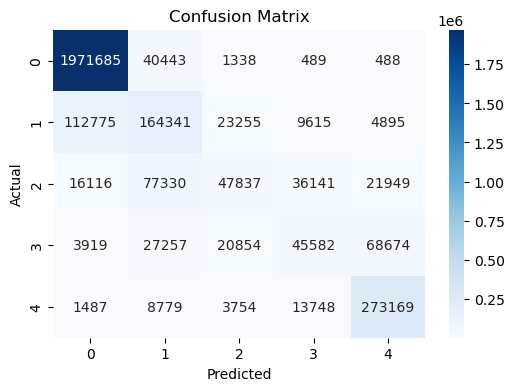


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96   2014443
           1       0.52      0.52      0.52    314881
           2       0.49      0.24      0.32    199373
           3       0.43      0.27      0.34    166286
           4       0.74      0.91      0.82    300937

    accuracy                           0.84   2995920
   macro avg       0.62      0.58      0.59   2995920
weighted avg       0.81      0.84      0.82   2995920



In [29]:
predict_full_dataset(model=hgb,
                     input_X=X_hgb,
                     input_y=y_hgb)

## 4. XGBoost
- One of the first fast, regularized GBDT libraries
- Performance on sample dataset:
  - Accuracy       : 0.87
  - Precision Score: 0.695
  - Recall Score   : 0.679
  - F1 Score       : 0.684
  - Poor performance on middle categories

In [30]:
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    enable_categorical=True,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

In [31]:
X_xgb = X_origin.copy()
y_xgb = y_origin.copy()
y_xgb = y_xgb.astype(int) - 1

### Sample dataset
- Accuracy       : 0.87
- Precision Score: 0.695
- Recall Score   : 0.679
- F1 Score       : 0.684


Accuracy       : 0.87
Precision Score: 0.695
Recall Score   : 0.679
F1 Score       : 0.684



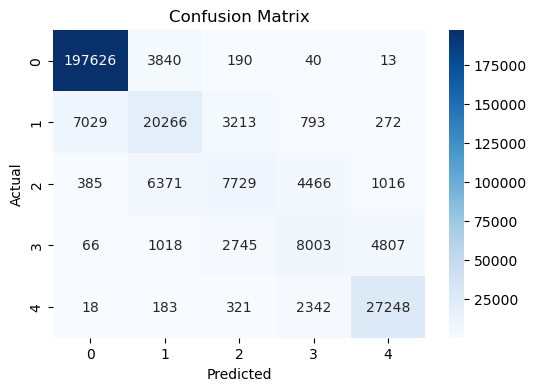


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    201709
           1       0.64      0.64      0.64     31573
           2       0.54      0.39      0.45     19967
           3       0.51      0.48      0.50     16639
           4       0.82      0.90      0.86     30112

    accuracy                           0.87    300000
   macro avg       0.70      0.68      0.68    300000
weighted avg       0.86      0.87      0.86    300000



In [32]:
predict_sample_dataset(model=xgb_model, 
                       input_X=X_xgb, 
                       input_y=y_xgb, 
                       sample_size=1000000)

## 5. LightGBM
- Microsoft’s optimized version of boosting (faster than XGBoost)
- Performance on sample dataset:
  - Accuracy : 0.891
  - Precision Score: 0.744
  - Recall Score : 0.738
  - F1 Score : 0.74
  - The best for now

In [33]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

In [34]:
X_lgbm = X_origin.copy()
y_lgbm = y_origin.copy()
y_lgbm = y_lgbm.astype(int) - 1

### Sample dataset
- Accuracy       : 0.891
- Precision Score: 0.744
- Recall Score   : 0.738
- F1 Score       : 0.74

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.396957
[LightGBM] [Info] Start training from score -2.251485
[LightGBM] [Info] Start training from score -2.709737
[LightGBM] [Info] Start training from score -2.891990
[LightGBM] [Info] Start training from score -2.298849
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.267

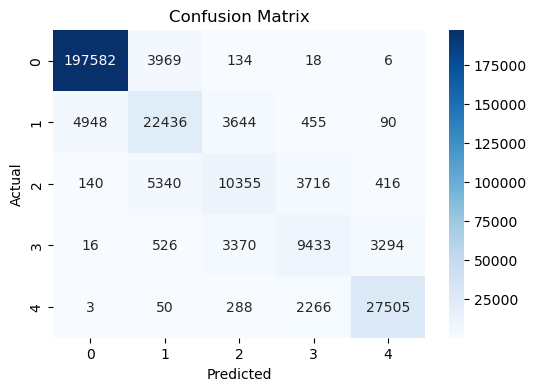


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000



In [35]:
predict_sample_dataset(model=lgbm_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')

## 6. CatBoostClassifier
- Yandex’s model focused on categorical feature handling
- Performance on sample dataset:
  - Accuracy       : 0.839
  - Precision Score: 0.636
  - Recall Score   : 0.619
  - F1 Score       : 0.626

In [36]:
cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=100,
    learning_rate=0.1,
    depth=6,
    bootstrap_type='Bernoulli',  # ✅ 改 bootstrap 類型
    subsample=0.1,               # ✅ 讓訓練快 10 倍
    early_stopping_rounds=10,
    random_seed=42,
    verbose=100
)

### Sample dataset

0:	learn: 1.3913768	test: 1.3914991	best: 1.3914991 (0)	total: 972ms	remaining: 1m 36s
99:	learn: 0.3947183	test: 0.3892685	best: 0.3892685 (99)	total: 53.1s	remaining: 0us

bestTest = 0.3892684946
bestIteration = 99

Accuracy       : 0.839
Precision Score: 0.636
Recall Score   : 0.619
F1 Score       : 0.626



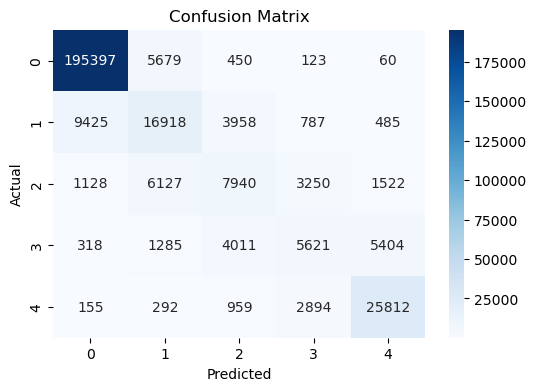


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    201709
           1       0.56      0.54      0.55     31573
           2       0.46      0.40      0.43     19967
           3       0.44      0.34      0.38     16639
           4       0.78      0.86      0.81     30112

    accuracy                           0.84    300000
   macro avg       0.64      0.62      0.63    300000
weighted avg       0.83      0.84      0.83    300000



In [37]:
predict_sample_dataset(model=cat_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_cat=True)

# Model prediction - Regression
- Use `busyness_percentile` from busyness_score_grid.ipynb as target variable

In [38]:
y_percentile = combined_df['busyness_percentile']

## 1. LinearRegression
- Performance on sample dataset
  - Accuracy       : 0.334
  - Precision Score: 0.464
  - Recall Score   : 0.303
  - F1 Score       : 0.202


In [39]:
linreg = LinearRegression()

### Sample dataset

Accuracy       : 0.334
Precision Score: 0.464
Recall Score   : 0.303
F1 Score       : 0.202



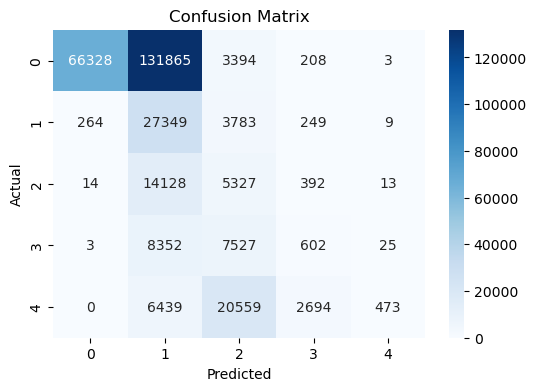


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.33      0.49    201798
           2       0.15      0.86      0.25     31654
           3       0.13      0.27      0.18     19874
           4       0.15      0.04      0.06     16509
           5       0.90      0.02      0.03     30165

    accuracy                           0.33    300000
   macro avg       0.46      0.30      0.20    300000
weighted avg       0.79      0.33      0.38    300000



In [40]:
predict_sample_dataset(model=linreg, 
                       input_X=X_sgd, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

## 2. Ridge / Lasso Regression
- [Ridge] Performance on simple dataset
    - Accuracy       : 0.334
    - Precision Score: 0.464
    - Recall Score   : 0.303
    - F1 Score       : 0.202
- [Lasso] Performance on simple dataset
    - Accuracy       : 0.661
    - Precision Score: 0.37
    - Recall Score   : 0.228
    - F1 Score       : 0.212

In [41]:
ridge_model = Ridge(alpha=1.0, random_state=42)
lasso_model = Lasso(alpha=0.1, random_state=42)

### Sample dataset

Accuracy       : 0.334
Precision Score: 0.464
Recall Score   : 0.303
F1 Score       : 0.202



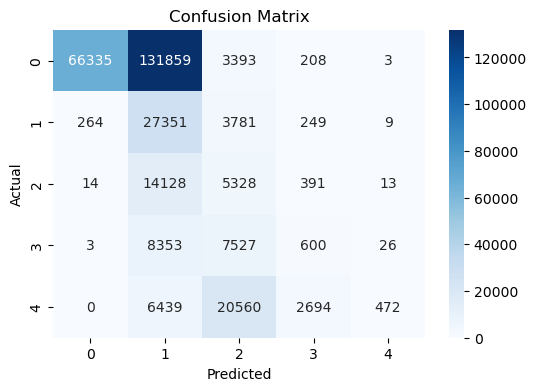


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.33      0.49    201798
           2       0.15      0.86      0.25     31654
           3       0.13      0.27      0.18     19874
           4       0.14      0.04      0.06     16509
           5       0.90      0.02      0.03     30165

    accuracy                           0.33    300000
   macro avg       0.46      0.30      0.20    300000
weighted avg       0.79      0.33      0.38    300000



In [42]:
predict_sample_dataset(model=ridge_model, 
                       input_X=X_sgd, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

Accuracy       : 0.661
Precision Score: 0.37
Recall Score   : 0.228
F1 Score       : 0.212



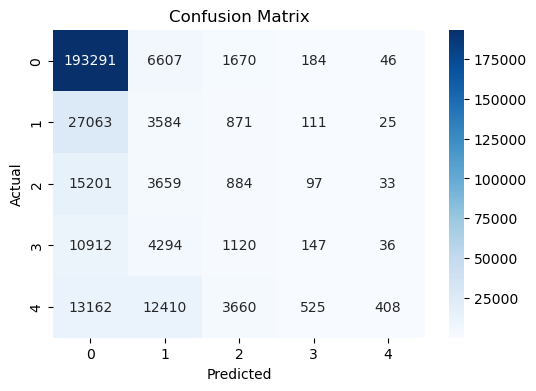


Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.96      0.84    201798
           2       0.12      0.11      0.12     31654
           3       0.11      0.04      0.06     19874
           4       0.14      0.01      0.02     16509
           5       0.74      0.01      0.03     30165

    accuracy                           0.66    300000
   macro avg       0.37      0.23      0.21    300000
weighted avg       0.60      0.66      0.58    300000



In [43]:
predict_sample_dataset(model=lasso_model, 
                       input_X=X_sgd, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

## 3. SGDRegressor
- Performance on sample dataset
    - Accuracy       : 0.314
    - Precision Score: 0.465
    - Recall Score   : 0.3
    - F1 Score       : 0.196

In [44]:
sgd_regressor = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

### Sample dataset

Accuracy       : 0.314
Precision Score: 0.465
Recall Score   : 0.3
F1 Score       : 0.196



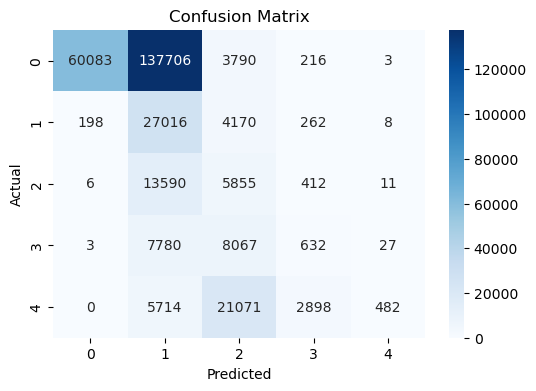


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.30      0.46    201798
           2       0.14      0.85      0.24     31654
           3       0.14      0.29      0.19     19874
           4       0.14      0.04      0.06     16509
           5       0.91      0.02      0.03     30165

    accuracy                           0.31    300000
   macro avg       0.46      0.30      0.20    300000
weighted avg       0.79      0.31      0.35    300000



In [45]:
predict_sample_dataset(model=sgd_regressor, 
                       input_X=X_sgd, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

## 4. HistGradientBoostingRegressor
- Performance on sample dataset:
    - Accuracy       : 0.766
    - Precision Score: 0.602
    - Recall Score   : 0.56
    - F1 Score       : 0.537
- Worse than HistGradientBoostingClassifier

In [46]:
hgb_regressor = HistGradientBoostingRegressor()

### Sample dataset

Accuracy       : 0.761
Precision Score: 0.601
Recall Score   : 0.55
F1 Score       : 0.523



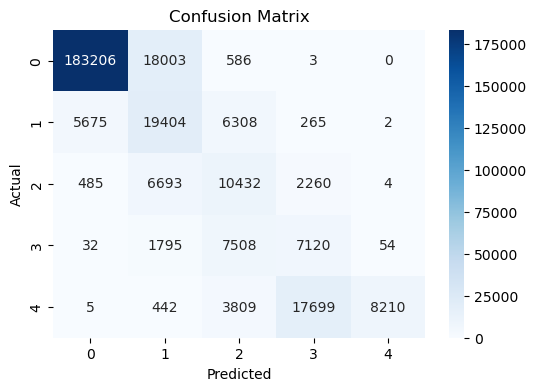


Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.91      0.94    201798
           2       0.42      0.61      0.50     31654
           3       0.36      0.52      0.43     19874
           4       0.26      0.43      0.32     16509
           5       0.99      0.27      0.43     30165

    accuracy                           0.76    300000
   macro avg       0.60      0.55      0.52    300000
weighted avg       0.83      0.76      0.77    300000



In [47]:
predict_sample_dataset(model=hgb_regressor, 
                       input_X=X_hgb, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous')

## 5. XGBoostRegressor
- Performance on sample dataset:
    - Accuracy       : 0.824
    - Precision Score: 0.683
    - Recall Score   : 0.713
    - F1 Score       : 0.674

In [48]:
xgb_regressor = xgb.XGBRegressor(
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)


### Sample dataset

Accuracy       : 0.824
Precision Score: 0.683
Recall Score   : 0.713
F1 Score       : 0.674



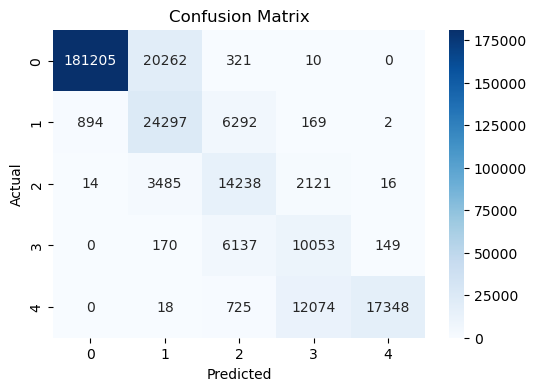


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.90      0.94    201798
           2       0.50      0.77      0.61     31654
           3       0.51      0.72      0.60     19874
           4       0.41      0.61      0.49     16509
           5       0.99      0.58      0.73     30165

    accuracy                           0.82    300000
   macro avg       0.68      0.71      0.67    300000
weighted avg       0.88      0.82      0.84    300000



In [49]:
predict_sample_dataset(model=xgb_regressor, 
                       input_X=X_xgb, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

## 6. LightGBMRegressor
- Performance on sample dataset:
    - Accuracy       : 0.843
    - Precision Score: 0.707
    - Recall Score   : 0.744
    - F1 Score       : 0.707

In [50]:
lgbm_regressor = lgb.LGBMRegressor(
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

### Sample dataset

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score 0.453099
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.038632	valid_0's l2: 0.00149243
Accuracy       : 0.849
Precision Score: 0.712
Recall Score   : 0.747
F1 Score       : 0.712



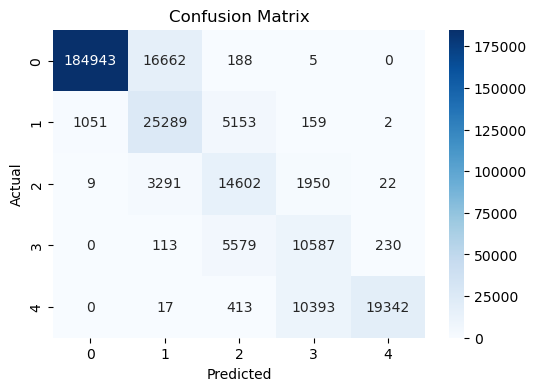


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.92      0.95    201798
           2       0.56      0.80      0.66     31654
           3       0.56      0.73      0.64     19874
           4       0.46      0.64      0.53     16509
           5       0.99      0.64      0.78     30165

    accuracy                           0.85    300000
   macro avg       0.71      0.75      0.71    300000
weighted avg       0.89      0.85      0.86    300000



In [51]:
predict_sample_dataset(model=lgbm_regressor,
                       input_X=X_lgbm,
                       input_y=y_percentile,
                       sample_size=1000000,
                       y_type='continuous',
                       is_lgbm=True, 
                       eval_metric='rmse')

## 7. CatBoostRegressor
- Performance on sample dataset:
    - Accuracy       : 0.759
    - Precision Score: 0.589
    - Recall Score   : 0.547
    - F1 Score       : 0.519

In [52]:
cat_regressor = CatBoostRegressor(
    loss_function='RMSE',
    iterations=100,
    learning_rate=0.1,
    depth=6,
    early_stopping_rounds=10,
    random_seed=42,
    verbose=100
)

### Sample dataset

0:	learn: 0.2013093	test: 0.2013922	best: 0.2013922 (0)	total: 312ms	remaining: 30.9s
99:	learn: 0.0775423	test: 0.0754148	best: 0.0754148 (99)	total: 22.5s	remaining: 0us

bestTest = 0.07541483086
bestIteration = 99

Accuracy       : 0.759
Precision Score: 0.589
Recall Score   : 0.547
F1 Score       : 0.519



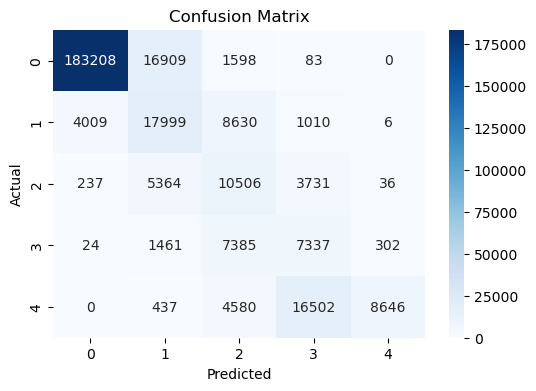


Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.91      0.94    201798
           2       0.43      0.57      0.49     31654
           3       0.32      0.53      0.40     19874
           4       0.26      0.44      0.32     16509
           5       0.96      0.29      0.44     30165

    accuracy                           0.76    300000
   macro avg       0.59      0.55      0.52    300000
weighted avg       0.83      0.76      0.77    300000



In [53]:
predict_sample_dataset(model=cat_regressor,
                       input_X=X_lgbm,
                       input_y=y_percentile,
                       sample_size=1000000,
                       y_type='continuous',
                       is_cat=True)

# Model comparison
- Among all 13 classification and regression models evaluated, LightGBM demonstrated the best performance on the sample dataset.
- Performance of LightGBM on the full dataset:
    - Accuracy       : 0.906
    - Precision Score: 0.781
    - Recall Score   : 0.776
    - F1 Score       : 0.778
- The trained model has been saved as `lgbm_model.pkl`

## Explore different combination of LightGBM's attributes on sample dataset
- No much difference, keep 'multiclass' * 'multi_logloss' combination

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.396957
[LightGBM] [Info] Start training from score -2.251485
[LightGBM] [Info] Start training from score -2.709737
[LightGBM] [Info] Start training from score -2.891990
[LightGBM] [Info] Start training from score -2.298849
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.267

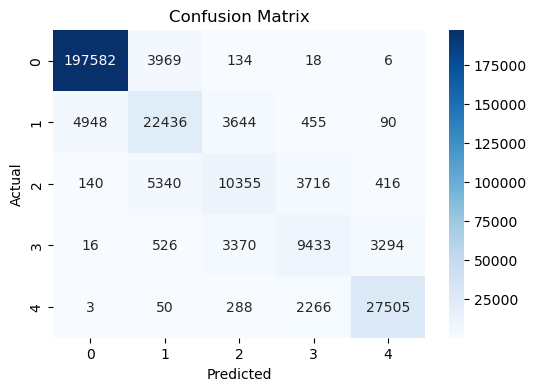


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000

===
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

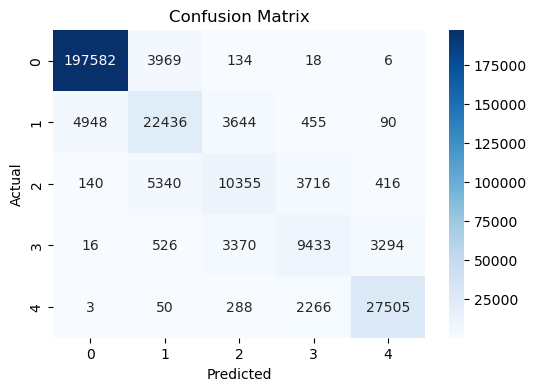


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000

===
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

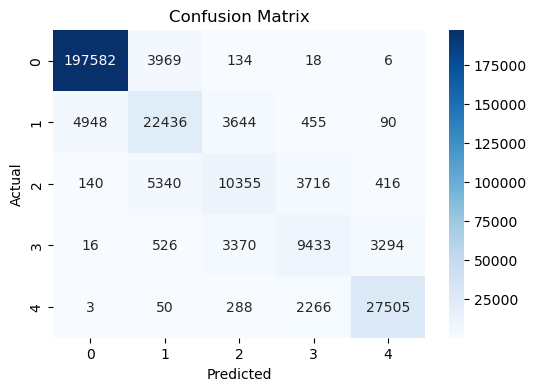


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000

===


In [54]:
# multiclass x ['multi_logloss', 'multi_error', 'auc_mu']
eval_metrics = ['multi_logloss', 'multi_error', 'auc_mu']
for eval_metric in eval_metrics:
    lgbm_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        learning_rate=0.1,
        num_leaves=64,
        n_estimators=100,
        random_state=42
    )
    
    predict_sample_dataset(model=lgbm_model,
                           input_X=X_lgbm,
                           input_y=y_lgbm,
                           sample_size=1000000,
                           y_type='categorical',
                           is_lgbm=True, 
                           eval_metric=eval_metric)
    print("===")

softmax
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.396957
[LightGBM] [Info] Start training from score -2.251485
[LightGBM] [Info] Start training from score -2.709737
[LightGBM] [Info] Start training from score -2.891990
[LightGBM] [Info] Start training from score -2.298849
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_loglos

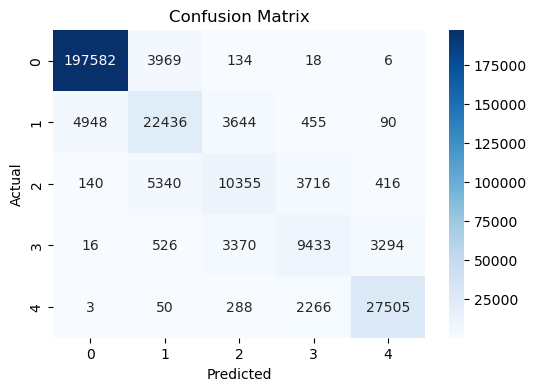


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000

===
ova
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 470654, number of negative: 229346
[LightGBM] [Info] Number of positive: 73670, number of negative: 626330
[LightGBM] [Info] Number of positive: 46588, number of negative: 653412
[LightGBM] [Info] Number of pos

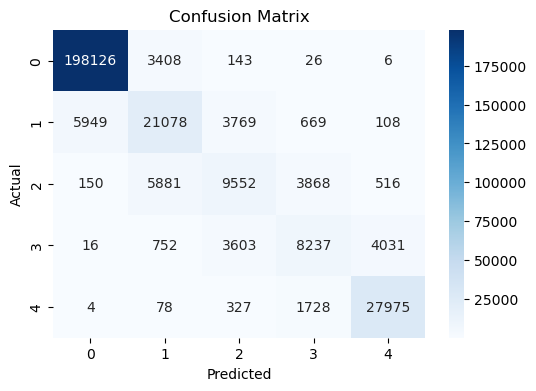


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.68      0.67      0.67     31573
           2       0.55      0.48      0.51     19967
           3       0.57      0.50      0.53     16639
           4       0.86      0.93      0.89     30112

    accuracy                           0.88    300000
   macro avg       0.72      0.71      0.72    300000
weighted avg       0.88      0.88      0.88    300000

===


In [55]:
# ['softmax', 'ova'] x 'multi_logloss'
objectives = ['softmax', 'ova']
for objective in objectives:
    lgbm_model = lgb.LGBMClassifier(
        objective=objective,
        num_class=5,
        learning_rate=0.1,
        num_leaves=64,
        n_estimators=100,
        random_state=42
    )
    print(objective)
    predict_sample_dataset(model=lgbm_model,
                           input_X=X_lgbm,
                           input_y=y_lgbm,
                           sample_size=1000000,
                           y_type='categorical',
                           is_lgbm=True, 
                           eval_metric='multi_logloss')
    print("===")

## LightGBM performance on full dataset

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.223406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2148
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.396908
[LightGBM] [Info] Start training from score -2.252814
[LightGBM] [Info] Start training from score -2.709826
[LightGBM] [Info] Start training from score -2.891299
[LightGBM] [Info] Start training from score -2.298106
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.24

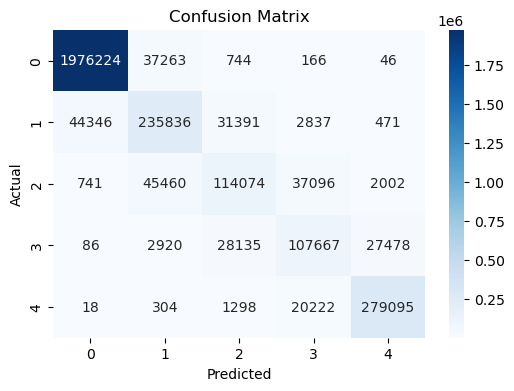


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98   2014443
           1       0.73      0.75      0.74    314881
           2       0.65      0.57      0.61    199373
           3       0.64      0.65      0.64    166286
           4       0.90      0.93      0.92    300937

    accuracy                           0.91   2995920
   macro avg       0.78      0.78      0.78   2995920
weighted avg       0.90      0.91      0.90   2995920



In [57]:
X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

lgbm_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        learning_rate=0.1,
        num_leaves=64,
        n_estimators=100,
        random_state=42
    )

cat_features = X_lgbm.select_dtypes('category').columns.tolist()

lgbm_model.fit(
    X_train_lgbm, y_train_lgbm,
    eval_set=[(X_test_lgbm, y_test_lgbm)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(10)]
)

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_lgbm)

## Save LightGBM model

In [ ]:
import joblib

joblib.dump(lgbm_model, 'lgbm_model.pkl')

['lgbm_model.pkl']